# Customer Segmentation: K-Means Clustering

## Overview
This notebook uses K-Means clustering to segment customers based on their RFM (Recency, Frequency, Monetary) values. Unlike manual RFM segmentation, K-Means finds natural groupings in the data.

## Objectives
1.  **Data Preprocessing:** Handle outliers and scale the data (StandardScaler).
2.  **Optimal K:** Use the Elbow Method to find the best number of clusters.
3.  **Clustering:** Apply K-Means and assign cluster labels.
4.  **Analysis:** Interpret the characteristics of each cluster.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

In [2]:
# Connect to the SQLite database
db_path = '../Project1 (DA)/olist.db'
conn = sqlite3.connect(db_path)

# Load RFM data (same query as before)
query = """
SELECT 
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    oi.price
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
"""
df = pd.read_sql(query, conn)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Calculate RFM
max_date = df['order_purchase_timestamp'].max()
ref_date = max_date + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (ref_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"Data loaded. Shape: {rfm.shape}")
display(rfm.head())

Data loaded. Shape: (93358, 4)


,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


## 1. Preprocessing
K-Means is sensitive to outliers and scale. We need to:
1.  **Log Transform:** To handle skewed distributions (especially Monetary and Frequency).
2.  **Scale:** To ensure all features have the same weight (mean=0, std=1).

In [3]:
# Check skewness
print("Skewness before transformation:")
print(rfm[['recency', 'frequency', 'monetary']].skew())

# Log transform (add 1 to avoid log(0))
rfm_log = rfm[['recency', 'frequency', 'monetary']].apply(np.log1p)

# Scale data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['recency', 'frequency', 'monetary'])

print("\nScaled Data Preview:")
display(rfm_scaled.head())

Skewness before transformation:
recency       0.447434
frequency    11.095156
monetary      9.746869
dtype: float64

Scaled Data Preview:


,recency,frequency,monetary
0,-0.470398,-0.17019,0.420860
1,-0.442315,-0.17019,-1.618982
2,1.202027,-0.17019,-0.256958
3,0.651893,-0.17019,-1.288977
4,0.536011,-0.17019,0.771782


## 2. Optimal K (Elbow Method)
We'll run K-Means for K=1 to 10 and plot the inertia (sum of squared distances) to find the 'elbow'.

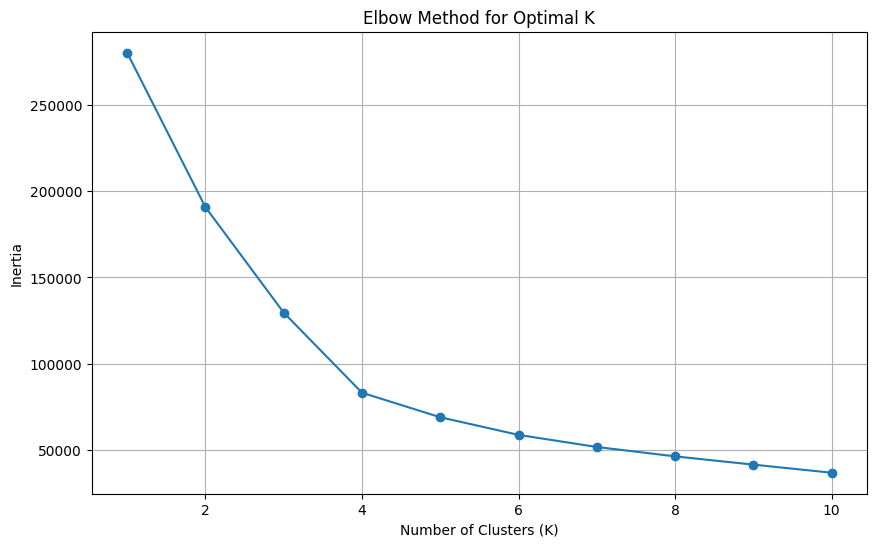

In [4]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

## 3. Clustering
Based on the Elbow plot (usually K=3 or K=4 is good for RFM), we'll choose K=4 for this analysis.

In [5]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"Clusters assigned. Counts per cluster:")
print(rfm['cluster'].value_counts())

Clusters assigned. Counts per cluster:
cluster
0    37747
1    36704
3    16106
2     2801
Name: count, dtype: int64


## 4. Cluster Analysis
Let's look at the mean RFM values for each cluster to interpret them.

In [6]:
cluster_summary = rfm.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_id': 'count'
}).reset_index()

display(cluster_summary)

,cluster,recency,frequency,monetary,customer_id
0,0,278.013749,1.000000,237.204159,37747
1,1,284.108762,1.000000,45.133364,36704
2,2,220.294538,2.113888,260.053106,2801
3,3,41.885633,1.000000,116.898606,16106
